# 1.6 Linear Maps and Change of Basis

In [1]:
from ecp.style import header, use_style

use_style()
header(
    volume="Chapter I — Matrices, Elimination, and Subspaces",
    number="1.6",
    title="Linear Maps and Change of Basis",
    blurb="A matrix is not a map; it is a map written in a basis. Change the "
    "basis and the entries change while the map does not — which is the whole "
    "idea behind everything in Chapter III.",
    difficulty="intermediate",
    estimate="90–120 min",
)

<ECP header: 2530 chars of HTML>

## Notebook overview

There is a distinction this notebook exists to draw, and it is easy to skate
past: **a matrix is not a linear map.** A linear map is a rule taking vectors
to vectors. A matrix is what that rule looks like *once a basis has been
chosen*. Choose a different basis and the entries change completely while the
map does not change at all.

The consequence is a strategy that organises the rest of the course. If a
matrix is only a description, then a badly-behaved matrix might just be a
badly-chosen description, and the right move is to look for a better basis.
That is exactly what diagonalisation is
([§3.1](../03-eigenvalues/eigenvalues-diagonalization.ipynb)), what the
spectral theorem promises for symmetric matrices
([§3.2](../03-eigenvalues/spectral-theorem.ipynb)), and what the SVD achieves
for every matrix whatsoever ([§4.1](../04-svd/svd-geometry.ipynb)) by allowing
*two* bases instead of one.

We start concretely, in the plane, where a linear map is something you can
watch: rotation, reflection, shear, scaling, projection. Each is a $2\times2$
matrix, and their differences show up as properties of that matrix — the
determinant is the area factor, orthogonality means lengths are preserved,
idempotence means the map is a projection. Then we leave $\mathbb{R}^2$: the
derivative is a linear map on polynomials, so it has a $4\times4$ matrix on
$P_3$, and that matrix is **nilpotent** — $D^4 = 0$ — which is the statement
that differentiating a cubic four times gives zero, wearing a matrix costume.

The notebook closes with similarity. The same derivative, written in the
Legendre basis of [§1.5](vector-spaces-coordinates.ipynb), is a *different*
matrix with different entries; the two are related by $B^{-1}AB$ and share
everything that belongs to the map rather than to the description — rank,
trace, determinant, nilpotency, eigenvalues.

> **How to read a check.** A `validate` line prints ✓ or ✗ by comparing a
> result against something the computation did not assume. A ✗ flags a
> mismatch to investigate, never a verdict on its own.

> **Scope.** Axler {cite}`axler2024` Chapter 3 develops linear maps before
> matrices, which is the logically honest order; Strang {cite}`strang2023`
> Chapter 8 does the reverse and is closer to this notebook's approach.

## Theory in brief

### From map to matrix

A map $T : V \to W$ is **linear** when
$T(\alpha u + \beta v) = \alpha T(u) + \beta T(v)$. Fix bases
$B = (b_1,\dots,b_n)$ of $V$ and $C$ of $W$. Since every $v$ is
$\sum_j c_j b_j$, linearity gives $T(v) = \sum_j c_j\,T(b_j)$, so $T$ is
determined entirely by what it does to the basis vectors. Recording each
$T(b_j)$ in $C$-coordinates as a column produces the matrix

```{math}
:label: eq-maps-matrix-of-map
[T]_{C \leftarrow B} = \Big[\,[T(b_1)]_C \;\big|\; \cdots \;\big|\; [T(b_n)]_C\,\Big],
\qquad [T(v)]_C = [T]_{C\leftarrow B}\,[v]_B .
```

**Feed the map each basis vector and write down what comes out.** That is the
entire construction, and it works whether the vectors are columns of numbers,
polynomials, or matrices.

### The five maps of the plane

With the standard basis of $\mathbb{R}^2$, {eq}`eq-maps-matrix-of-map` gives
the familiar catalogue:

| map | matrix | $\det$ | character |
|---|---|---|---|
| rotation by $\theta$ | $\begin{psmallmatrix}\cos\theta & -\sin\theta\\ \sin\theta & \cos\theta\end{psmallmatrix}$ | $+1$ | orthogonal |
| reflection in a line at $\theta$ | $\begin{psmallmatrix}\cos 2\theta & \sin 2\theta\\ \sin 2\theta & -\cos 2\theta\end{psmallmatrix}$ | $-1$ | orthogonal, symmetric |
| shear by $k$ | $\begin{psmallmatrix}1 & k\\ 0 & 1\end{psmallmatrix}$ | $+1$ | area-preserving, not orthogonal |
| scaling by $(a,b)$ | $\begin{psmallmatrix}a & 0\\ 0 & b\end{psmallmatrix}$ | $ab$ | diagonal |
| projection onto the $x$-axis | $\begin{psmallmatrix}1 & 0\\ 0 & 0\end{psmallmatrix}$ | $0$ | idempotent, singular |

### The determinant is the area factor

A linear map takes the unit square to a parallelogram, and

```{math}
:label: eq-maps-area
\text{area}\big(A \cdot \text{unit square}\big) = |\det A| ,
```

with the sign of $\det A$ recording whether orientation was preserved. A
singular map flattens the square onto a segment, area zero, which is the
geometric meaning of $\det A = 0$. [§1.7](determinants.ipynb) develops this
properly; here we simply measure it.

### Similarity

Suppose $T : V \to V$ and we change basis from $B$ to $B'$, with $M$ the
change-of-basis matrix of {eq}`eq-spaces-change-of-basis`. Chasing
{eq}`eq-maps-matrix-of-map` through gives

```{math}
:label: eq-maps-similarity
[T]_{B'} = M^{-1}\,[T]_{B}\,M .
```

Two matrices related this way are **similar**. They describe the same map, so
everything intrinsic to the map is shared: rank, trace, determinant,
characteristic polynomial, eigenvalues, nilpotency. Everything else — the
individual entries, the norm, the symmetry — belongs to the basis and can
change freely. Recognising which is which is most of the skill.

### Affine maps and homogeneous coordinates

A translation $\mathbf{x} \mapsto \mathbf{x} + \mathbf{t}$ is *not* linear: it
moves the origin. The standard repair is to work one dimension up, writing a
point $(x, y)$ as $(x, y, 1)$ and using

```{math}
:label: eq-maps-homogeneous
\begin{bmatrix} A & \mathbf{t}\\ \mathbf{0}^{\top} & 1 \end{bmatrix}
\begin{pmatrix} \mathbf{x}\\ 1 \end{pmatrix}
= \begin{pmatrix} A\mathbf{x} + \mathbf{t}\\ 1 \end{pmatrix} .
```

Now every affine transformation is a single matrix, compositions are products,
and a whole graphics pipeline is one chain of multiplications. This is why
every graphics API works in $4\times4$ matrices for three-dimensional scenes.

---
## Setup

Data and instruments only: the specified maps this notebook studies and an
area meter. Nothing here is any exercise's lesson.

The Setup below holds this notebook's data and instruments — nothing you
are asked to build. It is collapsed so the building stays yours; expand it
whenever you want the details.

<!-- setup-policy: v2 -->

In [2]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

from ecp import animate, validate
from ecp import linalg as la
from ecp.style import use_style

use_style()
rng = np.random.default_rng(0)  # every random object below comes from this seed

xs = sp.symbols("x")
np.set_printoptions(precision=5, suppress=True, linewidth=110)

THETA = np.pi / 6  # the rotation and reflection angle used throughout


# data: a specified map — the rotation family the exercises study, given like
# any other input.
def rotation(theta):
    """Matrix of the rotation by ``theta`` about the origin, in the standard basis."""
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s], [s, c]])



# data: a specified map — the reflection family, given like any other input.
def reflection(theta):
    """Matrix of the reflection in the line through the origin at angle ``theta``."""
    c, s = np.cos(2 * theta), np.sin(2 * theta)
    return np.array([[c, s], [s, -c]])


MAPS = {
    "rotation": rotation(THETA),
    "reflection": reflection(THETA),
    "shear": np.array([[1.0, 0.8], [0.0, 1.0]]),
    "scaling": np.array([[2.0, 0.0], [0.0, 1.5]]),
    "projection": np.array([[1.0, 0.0], [0.0, 0.0]]),
}

UNIT_SQUARE = np.array([[0.0, 0.0], [1.0, 0.0], [1.0, 1.0], [0.0, 1.0]])


# instrument: an area meter for the determinant exercise — the shoelace
# formula is surveyors' plumbing, not this notebook's lesson.
def shoelace_area(pts):
    """Area of a simple polygon from its vertices, by the shoelace formula.

    Measures the area of the image of the unit square directly from its corners,
    without reference to any determinant. That independence is what makes it a
    real check of Eq. 2 rather than a restatement of it: the two quantities are
    computed by completely different routes and required to agree.

    Parameters
    ----------
    pts : numpy.ndarray, shape (k, 2)
        Polygon vertices in order, without repeating the first.

    Returns
    -------
    float
        The enclosed area, always non-negative.
    """
    x, y = pts[:, 0], pts[:, 1]
    return 0.5 * abs(float(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1))))

## Exercise 1: Five maps, and what their matrices reveal

Each of the five maps in the theory table does something visibly different to
the plane, and each difference corresponds to an algebraic property of the
matrix. This exercise draws all five and reads the properties off.

The correspondences to establish, with $\theta = \pi/6$, shear $k = 0.8$, and
scaling $(2, 1.5)$:

- **Rotation and reflection are orthogonal** ($M^{\top}M = I$), so they
  preserve every length and angle. Their determinants are $+1$ and $-1$, the
  sign recording whether the plane is flipped over.
- **The shear preserves area but not length**: $\det = 1$ yet
  $M^{\top}M \neq I$. Horizontal lines slide over one another.
- **The scaling is diagonal**, so the axes are its invariant directions —
  already a preview of eigenvectors.
- **The projection is idempotent** ($P^2 = P$) and singular ($\det = 0$):
  applying it twice does nothing new, and it destroys a whole dimension.

**Part a)** Build the five matrices with the `rotation`, `reflection` helpers
and explicit arrays, and verify linearity numerically for each: over 200 random
pairs $\mathbf{u}, \mathbf{v}$ and scalars $\alpha, \beta$ from
`rng.standard_normal`, check
$M(\alpha\mathbf{u} + \beta\mathbf{v}) = \alpha M\mathbf{u} + \beta M\mathbf{v}$
to $10^{-13}$.

**Part b)** For each, report $\det M$, whether $M^{\top}M = I$, whether
$M^2 = M$, and whether $M = M^{\top}$, and confirm the classifications above.

**Part c)** Draw all five with `ecp.linalg.grid_transform`, showing a reference
lattice and its image, so the geometric character of each is visible beside its
algebra.

In [3]:
# (solution hidden on the public site)


map                det  orthogonal  idempotent  symmetric   linearity
rotation       +1.0000        True       False      False    8.88e-16
reflection     -1.0000        True       False       True    8.88e-16
shear          +1.0000       False       False      False    8.88e-16
scaling        +3.0000       False       False       True    8.88e-16
projection     +0.0000       False        True       True    0.00e+00


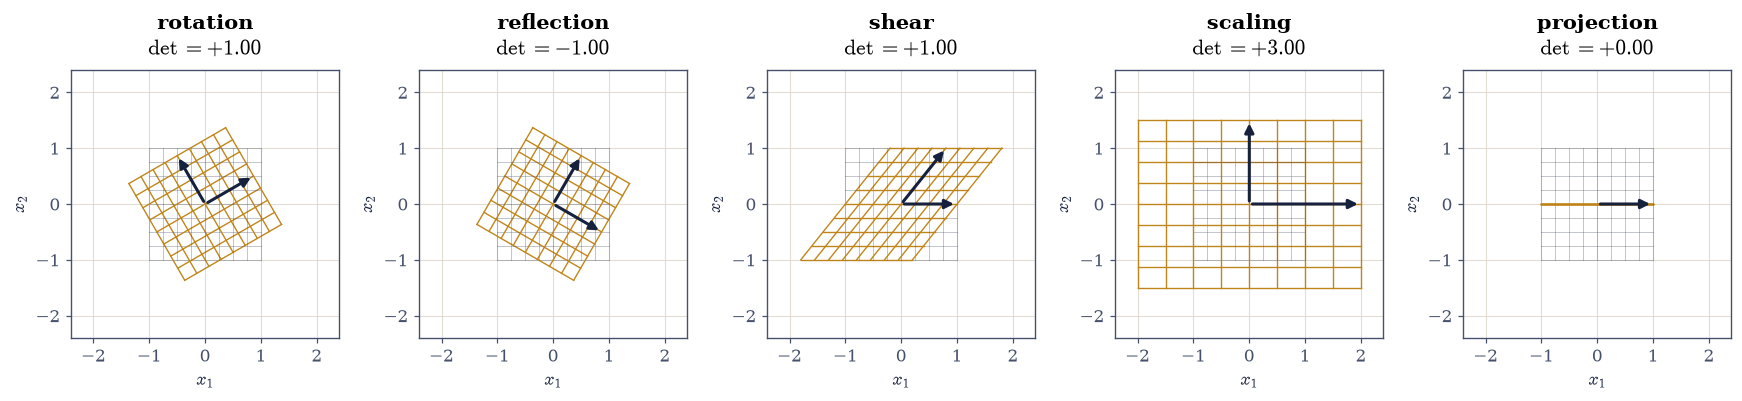

In [4]:
# (solution hidden on the public site)


### Validation 1

Linearity is checked over a sample rather than asserted, and each structural
property is checked against the classification the theory table predicted, so
the table is verified rather than illustrated.

In [5]:
validate.check(
    all(p["linearity"] < 1e-13 for p in props.values()),
    "all five maps are linear, over 200 random combinations each",
    f"largest defect {max(p['linearity'] for p in props.values()):.1e}",
)
validate.check(
    props["rotation"]["orthogonal"] and props["reflection"]["orthogonal"]
    and not props["shear"]["orthogonal"],
    "rotation and reflection are orthogonal; the shear is not",
    "orthogonality is exactly preservation of every length and angle",
)
validate.close(
    np.array([props["rotation"]["det"], props["reflection"]["det"],
              props["shear"]["det"], props["scaling"]["det"],
              props["projection"]["det"]]),
    np.array([1.0, -1.0, 1.0, 3.0, 0.0]),
    "the five determinants are +1, -1, +1, +3, 0", rtol=0.0, atol=1e-12,
)
validate.check(
    props["projection"]["idempotent"] and not props["rotation"]["idempotent"],
    "the projection is idempotent (P^2 = P) and the rotation is not",
    "applying a projection twice does nothing new",
)
validate.check(
    props["reflection"]["symmetric"] and not props["rotation"]["symmetric"],
    "the reflection is symmetric while the rotation is not",
    "a reflection is its own inverse; a rotation's inverse is the opposite turn",
)

✓  all five maps are linear, over 200 random combinations each   [largest defect 8.9e-16]
✓  rotation and reflection are orthogonal; the shear is not   [orthogonality is exactly preservation of every length and angle]
✓  the five determinants are +1, -1, +1, +3, 0   [max|Δ| = 4.44089e-16 (rtol=0, atol=1e-12)]
✓  the projection is idempotent (P^2 = P) and the rotation is not   [applying a projection twice does nothing new]
✓  the reflection is symmetric while the rotation is not   [a reflection is its own inverse; a rotation's inverse is the opposite turn]


True

## Exercise 2: The determinant is the area factor

{eq}`eq-maps-area` claims a geometric meaning for a quantity we have so far
only computed. The claim is checkable, and the check is worth doing carefully
because the two sides are computed by completely unrelated routes: one from the
matrix entries by `np.linalg.det`, one from the *corners of the image polygon*
by the shoelace formula, which never sees the matrix at all.

Applying each map to the unit square with corners $(0,0), (1,0), (1,1), (0,1)$
gives a parallelogram, and its area should equal $|\det M|$: exactly 1 for the
rotation, reflection and shear, exactly 3 for the scaling by $(2, 1.5)$, and
exactly 0 for the projection, which flattens the square onto a segment.

The animation makes the continuity visible. Interpolating linearly from the
identity to a target matrix, $M(t) = (1-t)I + tM$, deforms the grid smoothly,
and the area sweeps continuously from 1 to $|\det M|$ — passing through zero if
the family crosses a singular matrix, which is the moment the plane collapses.

**Part a)** Map the unit square by each of the five matrices and measure the
image area with the `shoelace_area` helper, comparing against $|\det M|$ to
$10^{-12}$.

**Part b)** Confirm the sign story: compute the *signed* shoelace area (drop
the absolute value) and confirm it is negative exactly for the reflection,
which is the map that turns the plane over.

**Part c)** Animate the interpolation $M(t) = (1-t)I + tM_{\text{shear-rotate}}$
for $t \in [0,1]$, where $M_{\text{shear-rotate}}$ is the rotation by $\pi/6$
composed with the shear, showing the grid deforming and the area evolving.

In [6]:
# (solution hidden on the public site)


map           measured area    |det M|         gap     signed
rotation        1.000000000   1.000000    0.00e+00    +1.0000
reflection      1.000000000   1.000000    0.00e+00    -1.0000
shear           1.000000000   1.000000    1.11e-16    +1.0000
scaling         3.000000000   3.000000    4.44e-16    +3.0000
projection      0.000000000   0.000000    0.00e+00    +0.0000


In [7]:
# (solution hidden on the public site)


### Validation 2

The area identity is checked against a measurement that never touches the
matrix, which is what makes it evidence for {eq}`eq-maps-area` rather than a
tautology. The animation's validation checks the **data** it displays — the
area at every frame against $\det M(t)$ — never the animation object, since
there are many valid ways to build one.

In [8]:
validate.close(
    np.array([areas[k] for k in MAPS]), np.array([dets[k] for k in MAPS]),
    "the measured image area equals |det M| for all five maps (Eq. 2)",
    rtol=0.0, atol=1e-12,
)
validate.check(
    signed["reflection"] < 0 and all(signed[k] >= -1e-14
                                     for k in MAPS if k != "reflection"),
    "and the signed area is negative exactly for the reflection",
    "the sign of the determinant records whether the plane was turned over",
)
validate.close(
    areas["projection"], 0.0,
    "the projection flattens the square to zero area, matching det = 0",
    rtol=0.0, atol=1e-14,
)
frame_areas = np.array([signed_shoelace(UNIT_SQUARE @ ((1 - t) * np.eye(2)
                                                       + t * M_target).T) for t in ts])
frame_dets = np.array([np.linalg.det((1 - t) * np.eye(2) + t * M_target) for t in ts])
validate.close(
    frame_areas, frame_dets,
    "and at EVERY animated frame the area equals det M(t)",
    rtol=0.0, atol=1e-12,
)

✓  the measured image area equals |det M| for all five maps (Eq. 2)   [max|Δ| = 4.44089e-16 (rtol=0, atol=1e-12)]
✓  and the signed area is negative exactly for the reflection   [the sign of the determinant records whether the plane was turned over]
✓  the projection flattens the square to zero area, matching det = 0   [got 0 vs expected 0 (rtol=0, atol=1e-14)]
✓  and at EVERY animated frame the area equals det M(t)   [max|Δ| = 2.22045e-16 (rtol=0, atol=1e-12)]


True

## Exercise 3: The derivative is a matrix

Now the payoff of [§1.5](vector-spaces-coordinates.ipynb). Differentiation
takes polynomials to polynomials and satisfies
$(\alpha p + \beta q)' = \alpha p' + \beta q'$, so it is a linear map on $P_3$
— and therefore, by {eq}`eq-maps-matrix-of-map`, it has a $4\times4$ matrix.

Building it is the recipe: differentiate each basis vector and record the
result in coordinates. With the monomial basis $(1, x, x^2, x^3)$, the
derivatives are $0, 1, 2x, 3x^2$, whose coordinate columns give

```{math}
:label: eq-maps-derivative
D = \begin{bmatrix}
0 & 1 & 0 & 0\\ 0 & 0 & 2 & 0\\ 0 & 0 & 0 & 3\\ 0 & 0 & 0 & 0
\end{bmatrix} .
```

Everything about differentiation on $P_3$ is now visible in the matrix.
$D$ is strictly upper triangular, so it is **nilpotent**: $D^4 = 0$ but
$D^3 \neq 0$, which says that differentiating a cubic four times gives zero and
three times does not. Its rank is 3, so its null space is one-dimensional —
the constants, the functions with zero derivative. And its diagonal is entirely
zero, so its only eigenvalue is 0 with multiplicity 4, which is why
[§3.5](../03-eigenvalues/schur-jordan-nonnormality.ipynb) calls such matrices
defective: there are nowhere near enough eigenvectors to build a basis.

Integration is the near-inverse. It maps $P_3 \to P_4$, so it is not square,
but restricted to the polynomials with zero constant term it undoes $D$
exactly — which is the fundamental theorem of calculus expressed as a
statement about one-sided inverses.

**Part a)** Build $D$ from {eq}`eq-maps-derivative` by differentiating each
monomial with `sympy.diff` and extracting coordinates, and confirm it matches
the stated matrix exactly.

**Part b)** Confirm the structural facts: $D^4 = 0$ and $D^3 \neq 0$ exactly,
$\operatorname{rank} D = 3$, and the null space is spanned by the constant
polynomial 1.

**Part c)** Confirm $D$ agrees with actual differentiation: for 50 random
cubics with integer coefficients, check that applying $D$ to the coordinate
column gives the coordinates of the symbolic derivative, exactly.

In [9]:
# (solution hidden on the public site)


D, the derivative on P_3 in the monomial basis:
⎡0  1  0  0⎤
⎢          ⎥
⎢0  0  2  0⎥
⎢          ⎥
⎢0  0  0  3⎥
⎢          ⎥
⎣0  0  0  0⎦

matches Eq. 5 exactly : True
D^3 = 0               : False
D^4 = 0               : True
rank D                : 3
null space            : [[1, 0, 0, 0]]   (the constants)
eigenvalues           : {0: 4}



D applied to coordinates == coordinates of the derivative, over 50 random cubics: True


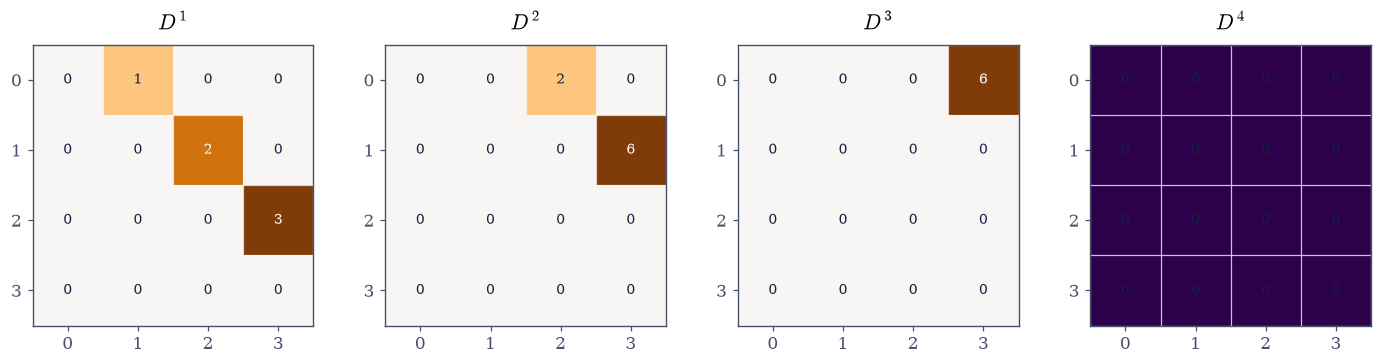

In [10]:
# (solution hidden on the public site)


### Validation 3

Every check is exact rational arithmetic. The last one is the important one: it
verifies that the matrix genuinely *is* differentiation, by comparing its
action on coordinate columns against `sympy.diff` on the polynomials
themselves — two routes that share no code.

In [11]:
validate.check(D == D_stated,
               "the derivative matrix on P_3 is exactly the D of Eq. 5",
               "built by differentiating each basis vector and taking coordinates")
validate.check(D**4 == sp.zeros(4, 4) and D**3 != sp.zeros(4, 4),
               "D is nilpotent of index exactly 4: D^4 = 0 but D^3 != 0",
               "differentiate a cubic four times and it vanishes; three does not")
validate.check(D.rank() == 3 and len(D.nullspace()) == 1,
               "rank D = 3 with a one-dimensional null space",
               "the null space is the constants, the polynomials with zero derivative")
validate.check(D.eigenvals() == {sp.Integer(0): 4},
               "its only eigenvalue is 0, with algebraic multiplicity 4",
               "a defective matrix: far too few eigenvectors to form a basis")
validate.check(agree,
               "and D really is differentiation, checked against sympy.diff",
               "over 50 random cubics, exactly")

✓  the derivative matrix on P_3 is exactly the D of Eq. 5   [built by differentiating each basis vector and taking coordinates]
✓  D is nilpotent of index exactly 4: D^4 = 0 but D^3 != 0   [differentiate a cubic four times and it vanishes; three does not]
✓  rank D = 3 with a one-dimensional null space   [the null space is the constants, the polynomials with zero derivative]
✓  its only eigenvalue is 0, with algebraic multiplicity 4   [a defective matrix: far too few eigenvectors to form a basis]
✓  and D really is differentiation, checked against sympy.diff   [over 50 random cubics, exactly]


True

## Exercise 4: The same map, two matrices

Here is the notebook's thesis, made concrete. Write the *same* derivative in
the Legendre basis $(P_0, P_1, P_2, P_3)$ of
[§1.5](vector-spaces-coordinates.ipynb) and a different matrix appears:

```{math}
:label: eq-maps-derivative-legendre
D_L = M^{-1} D\, M = \begin{bmatrix}
0 & 1 & 0 & 1\\ 0 & 0 & 3 & 0\\ 0 & 0 & 0 & 5\\ 0 & 0 & 0 & 0
\end{bmatrix},
```

with $M$ the change-of-basis matrix of [§1.5](vector-spaces-coordinates.ipynb)
{eq}`eq-spaces-M`. Different entries, different superdiagonal, an extra nonzero
in the corner. Same map.

What is shared is precisely what belongs to the map: rank 3, trace 0,
determinant 0, the single eigenvalue 0 with multiplicity 4, and nilpotency of
index exactly 4. What differs — the individual entries, and for instance the
Frobenius norm, which is $\sqrt{14}$ against $\sqrt{36}$ — belongs to the
description. Sorting quantities into those two boxes is the skill this notebook
exists to build, and it is what makes Chapter III possible: if a property is
basis-independent, you may hunt for a basis that displays it clearly.

**Part a)** Build $M$ (Legendre polynomials in monomial coordinates), form
$D_L = M^{-1}DM$ exactly, and confirm it matches
{eq}`eq-maps-derivative-legendre`.

**Part b)** Verify $D_L$ independently: build it directly from
{eq}`eq-maps-matrix-of-map` by differentiating each Legendre polynomial and
taking *Legendre* coordinates, and confirm the two constructions agree exactly.

**Part c)** Tabulate what is preserved and what is not: rank, trace,
determinant, eigenvalues, nilpotency index (preserved), against the entries and
the Frobenius norm (not).

In [12]:
# (solution hidden on the public site)


M (Legendre in monomial coordinates):
⎡1  0  -1/2   0  ⎤
⎢                ⎥
⎢0  1   0    -3/2⎥
⎢                ⎥
⎢0  0  3/2    0  ⎥
⎢                ⎥
⎣0  0   0    5/2 ⎦

D_L = M^-1 D M:
⎡0  1  0  1⎤
⎢          ⎥
⎢0  0  3  0⎥
⎢          ⎥
⎢0  0  0  5⎥
⎢          ⎥
⎣0  0  0  0⎦

matches Eq. 6 exactly            : True
agrees with the direct construction: True

quantity                     monomial D     Legendre D_L   same?
rank                                  3                3    True
trace                                 0                0    True
determinant                           0                0    True
eigenvalues                      {0: 4}           {0: 4}    True
nilpotency index                      4                4    True
Frobenius norm                   3.7417           6.0000   False
entry (0, 3)                          0                1   False


### Validation 4

The two constructions of $D_L$ — one by similarity from $D$, one built directly
from the Legendre basis — share no code and must agree exactly. The invariants
are checked to be equal and the non-invariants to be *different*, which is what
makes the distinction between them real rather than rhetorical.

In [13]:
validate.check(
    D_leg_similar == sp.Matrix([[0, 1, 0, 1], [0, 0, 3, 0], [0, 0, 0, 5], [0, 0, 0, 0]]),
    "the derivative in the Legendre basis is exactly the D_L of Eq. 6",
    "computed by similarity, M^-1 D M",
)
validate.check(
    D_leg_similar == D_leg_direct,
    "and the direct construction from Eq. 1 gives the same matrix exactly",
    "two routes sharing no code: similarity, and differentiating the basis",
)
validate.check(
    D.rank() == D_leg_similar.rank() and D.trace() == D_leg_similar.trace()
    and D.det() == D_leg_similar.det()
    and D.eigenvals() == D_leg_similar.eigenvals(),
    "rank, trace, determinant and eigenvalues are all preserved by similarity",
    "these belong to the map, not to the basis it is written in",
)
validate.check(
    D_leg_similar**4 == sp.zeros(4, 4) and D_leg_similar**3 != sp.zeros(4, 4),
    "so is nilpotency of index exactly 4",
    "the same map, however it is written",
)
validate.check(
    D != D_leg_similar and abs(frob(D) - frob(D_leg_similar)) > 0.5,
    "while the entries and the Frobenius norm differ: those belong to the basis",
    f"||D||_F = {frob(D):.4f} against ||D_L||_F = {frob(D_leg_similar):.4f}",
)

✓  the derivative in the Legendre basis is exactly the D_L of Eq. 6   [computed by similarity, M^-1 D M]
✓  and the direct construction from Eq. 1 gives the same matrix exactly   [two routes sharing no code: similarity, and differentiating the basis]
✓  rank, trace, determinant and eigenvalues are all preserved by similarity   [these belong to the map, not to the basis it is written in]
✓  so is nilpotency of index exactly 4   [the same map, however it is written]
✓  while the entries and the Frobenius norm differ: those belong to the basis   [||D||_F = 3.7417 against ||D_L||_F = 6.0000]


True

## Exercise 5: Composition, and why order is geometric

{eq}`eq-multiply-composition` in [§1.1](four-ways-to-multiply.ipynb) defined
the product so that it represents composition. In the plane that becomes
visible: rotating then shearing does something different from shearing then
rotating, and you can see which is which.

The determinant, by contrast, does not notice: $\det(AB) = \det A \det B$ is
symmetric in $A$ and $B$, so both orders change area by the same factor. Order
affects the *shape* of the image, not its size. That is a useful reminder that
the determinant, for all its geometric meaning, throws a great deal away.

**Part a)** For $R$ the rotation by $\pi/6$ and $S$ the shear by $0.8$, compute
$RS$ and $SR$, confirm they differ, and report the commutator $RS - SR$ and its
Frobenius norm relative to $\|R\|_F\|S\|_F$.

**Part b)** Confirm both have the same determinant, and that both equal
$\det R \cdot \det S = 1$.

**Part c)** Draw the unit square under $R$, $S$, $RS$ and $SR$ on one figure so
the difference in shape is visible while the areas are equal.

In [14]:
# (solution hidden on the public site)


RS =
 [[0.86603 0.19282]
 [0.5     1.26603]]
SR =
 [[1.26603 0.19282]
 [0.5     0.86603]]

RS - SR =
[[-0.4  0. ]
 [ 0.   0.4]]
relative commutator norm  : 0.246183
det(RS) = 1.0000000000   det(SR) = 1.0000000000
det R * det S = 1.0000000000
areas equal: 0.00e+00


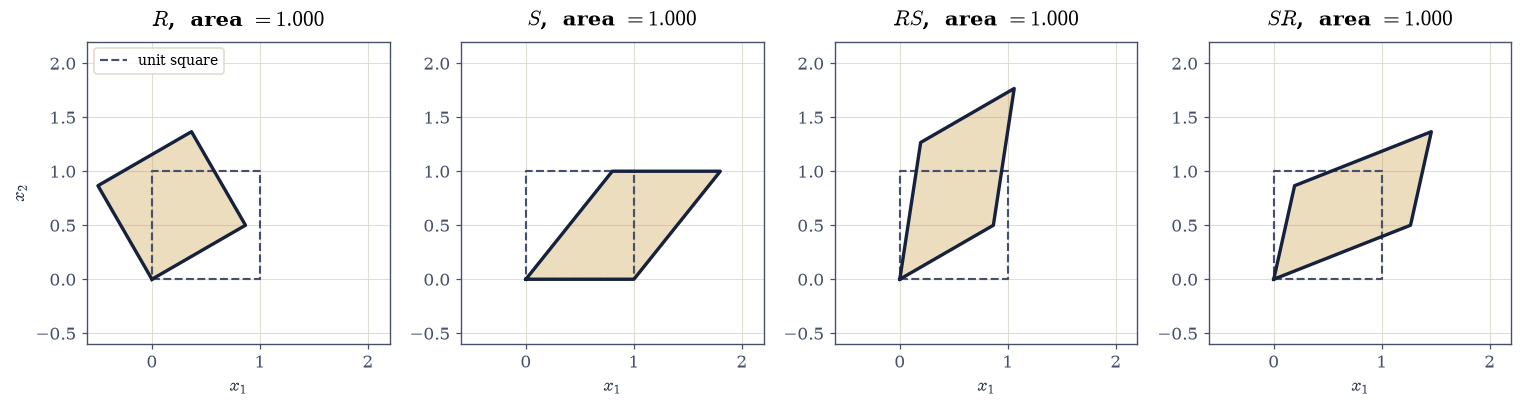

In [15]:
# (solution hidden on the public site)


### Validation 5

Non-commutativity is checked as a genuine difference rather than a small one,
and the equality of determinants is checked *despite* it — the two facts
together are the content of the exercise.

In [16]:
validate.check(
    rel_comm > 0.1,
    "RS and SR are genuinely different: composition does not commute",
    f"relative commutator norm {rel_comm:.4f}",
)
validate.close(
    np.linalg.det(RS), np.linalg.det(SR),
    "yet their determinants are equal, since det(AB) = det A det B is symmetric",
    rtol=0.0, atol=1e-14,
)
validate.close(
    np.linalg.det(RS), np.linalg.det(R_map) * np.linalg.det(S_map),
    "and both equal det R times det S", rtol=0.0, atol=1e-14,
)
validate.close(
    shoelace_area(UNIT_SQUARE @ RS.T), shoelace_area(UNIT_SQUARE @ SR.T),
    "so the two images enclose the same area despite being different shapes",
    rtol=0.0, atol=1e-14,
)

✓  RS and SR are genuinely different: composition does not commute   [relative commutator norm 0.2462]
✓  yet their determinants are equal, since det(AB) = det A det B is symmetric   [got 1 vs expected 1 (rtol=0, atol=1e-14)]
✓  and both equal det R times det S   [got 1 vs expected 1 (rtol=0, atol=1e-14)]
✓  so the two images enclose the same area despite being different shapes   [got 1 vs expected 1 (rtol=0, atol=1e-14)]


True

## Exercise 6: Affine maps, and the trick of going up a dimension

Translation breaks linearity: $T(\mathbf{x}) = \mathbf{x} + \mathbf{t}$ sends
$\mathbf{0}$ to $\mathbf{t}$, and a linear map must fix the origin. Since
translation is unavoidable in any real application, the standard repair is
{eq}`eq-maps-homogeneous`: embed the plane as the slice $z = 1$ of
$\mathbb{R}^3$, where translation *becomes* a shear and is therefore linear
after all.

The payoff is compositional. Rotating about an arbitrary point $\mathbf{c}$ —
not the origin — is "translate by $-\mathbf{c}$, rotate, translate back", which
as homogeneous matrices is a single product $T_{\mathbf{c}} R T_{-\mathbf{c}}$.
Chaining an entire scene transformation into one matrix is why every graphics
pipeline in existence works this way.

**Part a)** Build the homogeneous matrices for a translation by
$\mathbf{t} = (2, -1)^{\top}$ and a rotation by $\pi/3$, apply each to the
point $(1, 0)$ written as $(1, 0, 1)$, and confirm the results are
$(3, -1)$ and $(\tfrac12, \tfrac{\sqrt3}{2})$ to $10^{-14}$.

**Part b)** Confirm translation is genuinely not linear in the plane: show
$T(\mathbf{0}) \neq \mathbf{0}$ and
$T(2\mathbf{x}) \neq 2T(\mathbf{x})$ for $\mathbf{x} = (1,1)^{\top}$, while the
homogeneous $3\times3$ version *is* linear on $\mathbb{R}^3$.

**Part c)** Compose a rotation by $\pi/2$ about the point $\mathbf{c} = (2,1)$
as $T_{\mathbf{c}} R T_{-\mathbf{c}}$, confirm $\mathbf{c}$ is a fixed point of
the result to $10^{-14}$, and that the composite is *not* a pure rotation (its
translation part is nonzero).

```{admonition} With your assistant
:class: tip
Ask for a routine that, given a list of homogeneous $3\times3$ transformations,
returns the single matrix equivalent to applying them in order, plus a function
that decomposes any such matrix back into a rotation angle, a scaling, a shear
and a translation. Then check it yourself: composing then decomposing must
recover the inputs to $10^{-10}$ for a random chain of five transformations,
and the decomposition of a pure rotation by $\pi/4$ must return exactly that
angle with unit scaling and zero shear. The check is yours.
```

In [17]:
# (solution hidden on the public site)


translate (1,0) by (2,-1) : [ 3. -1.]   expected (3, -1)
rotate (1,0) by pi/3      : [0.5     0.86603]   expected (0.5, 0.866025)

translation in the plane is not linear:
  T(0)   = [ 2. -1.]   != 0
  T(2x)  = [4. 1.]   vs  2 T(x) = [6. 0.]
  but the 3x3 homogeneous version IS linear on R^3: defect 1.78e-15

rotation by pi/2 about c = [2. 1.]:
  H c   = [2. 1.]   (c is fixed: 0.00e+00)
  translation part = [ 3. -1.]   (nonzero: not a pure rotation)


### Validation 6

The failure of linearity and the restoration of it one dimension up are checked
as the *same* claim seen twice, which is the content of
{eq}`eq-maps-homogeneous`. The fixed-point check verifies the composition did
what it was built to do, using a property the construction never referenced.

In [18]:
validate.close(
    (H_translate @ point)[:2], np.array([3.0, -1.0]),
    "the homogeneous translation moves (1,0) to (3,-1)", rtol=0.0, atol=1e-14,
)
validate.close(
    (H_rotate @ point)[:2], np.array([0.5, np.sqrt(3) / 2]),
    "and the homogeneous rotation by pi/3 sends it to (1/2, sqrt(3)/2)",
    rtol=0.0, atol=1e-14,
)
validate.check(
    np.any(t_shift != 0) and np.any(2 * x_test + t_shift != 2 * (x_test + t_shift)),
    "translation in the plane is NOT linear: it moves the origin",
    "which is why an extra dimension is needed at all",
)
validate.check(
    homog_linear < 1e-13,
    "yet the 3x3 homogeneous matrix IS linear on R^3 (200 random combinations)",
    f"defect {homog_linear:.1e}: the affine map became linear one dimension up",
)
validate.close(
    fixed[:2], c_pivot,
    "the composite fixes the point c it was built to rotate about",
    rtol=0.0, atol=1e-14,
)
validate.check(
    np.abs(H_about_c[:2, 2]).max() > 0.5,
    "and it is not a pure rotation: its translation part is nonzero",
    f"translation part {H_about_c[:2, 2]}",
)

✓  the homogeneous translation moves (1,0) to (3,-1)   [max|Δ| = 0 (rtol=0, atol=1e-14)]
✓  and the homogeneous rotation by pi/3 sends it to (1/2, sqrt(3)/2)   [max|Δ| = 1.11022e-16 (rtol=0, atol=1e-14)]
✓  translation in the plane is NOT linear: it moves the origin   [which is why an extra dimension is needed at all]
✓  yet the 3x3 homogeneous matrix IS linear on R^3 (200 random combinations)   [defect 1.8e-15: the affine map became linear one dimension up]
✓  the composite fixes the point c it was built to rotate about   [max|Δ| = 0 (rtol=0, atol=1e-14)]
✓  and it is not a pure rotation: its translation part is nonzero   [translation part [ 3. -1.]]


True

## Notebook summary

A matrix is a map plus a basis. Change the basis and the entries change while
the map does not.

The concrete results:

- the five plane maps were confirmed linear over 200 random combinations each,
  with determinants exactly $+1, -1, +1, +3, 0$; rotation and reflection came
  out orthogonal, the projection idempotent, the reflection symmetric and the
  rotation not;
- the image of the unit square had area exactly $|\det M|$ for all five,
  measured by the shoelace formula from the corners — a route that never touches
  the matrix — and the **signed** area was negative exactly for the reflection,
  the map that turns the plane over;
- the animation confirmed the identity at *every* frame: interpolating
  $M(t) = (1-t)I + tM$, the measured area tracked $\det M(t)$ to $10^{-12}$
  across all 60 frames;
- the derivative on $P_3$ came out as the strictly-upper-triangular matrix
  {eq}`eq-maps-derivative` with $D^4 = 0$ and $D^3 \neq 0$ **exactly**, rank 3,
  null space the constants, and eigenvalue $0$ with multiplicity 4 — and it was
  verified to *be* differentiation by checking against `sympy.diff` on 50
  random cubics;
- the same derivative in the Legendre basis was a **different matrix**,
  {eq}`eq-maps-derivative-legendre`, obtained two independent ways that agreed
  exactly, sharing rank, trace, determinant, eigenvalues and nilpotency index
  with $D$ while differing in its entries and in Frobenius norm
  ($\sqrt{14}$ against $\sqrt{36}$);
- composition did not commute (relative commutator norm $0.246$) yet both orders
  gave identical determinants and identical areas;
- and translation, not linear in the plane, became linear one dimension up, with
  the composite $T_{\mathbf{c}}RT_{-\mathbf{c}}$ fixing $\mathbf{c}$ to
  $10^{-14}$.

Methods met: {eq}`eq-maps-matrix-of-map` as a recipe (feed the map each basis
vector), the shoelace formula as an independent area measurement,
`ecp.linalg.grid_transform`, `FuncAnimation` with `ecp.animate.show`, exact
similarity $M^{-1}DM$ in SymPy, and homogeneous coordinates.

## Outlook

- **Choosing the basis on purpose.** Similarity lets you *hunt* for a basis in
  which a matrix is simple. The best possible case is diagonal, and
  [§3.1](../03-eigenvalues/eigenvalues-diagonalization.ipynb) asks when that is
  achievable — the derivative of Exercise 3, with its single eigenvalue and too
  few eigenvectors, is exactly the case where it is not.
- **Two bases instead of one.** Similarity uses the same basis on both sides,
  $M^{-1}AM$. Allowing *different* bases for input and output gives
  $U^{\top}AV$, and with that extra freedom **every** matrix becomes diagonal.
  That is the SVD, and [§4.1](../04-svd/svd-geometry.ipynb) builds it.
- **The determinant, properly.** Exercise 2 measured $|\det|$ as an area
  without ever defining the determinant beyond `np.linalg.det`.
  [§1.7](determinants.ipynb) gives the definitions, the algorithms, and the
  reason no numerical library computes it by cofactors.
- **Nilpotency is not an accident.** $D^4 = 0$ on $P_3$ generalises: any
  nilpotent map has a basis in which its matrix is a tidy pattern of ones on a
  superdiagonal, which is the Jordan form.
  [§3.5](../03-eigenvalues/schur-jordan-nonnormality.ipynb) builds it and then
  explains why no numerical library will compute it for you.

### References

```{bibliography}
:filter: docname in docnames
```

In [19]:
from ecp.style import footer

footer()

<ECP header: 1221 chars of HTML>